In [164]:
# load settings
import copy
import re
import typing as t
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.optimize import curve_fit

np.random.seed(42)  # For reproducibility
data_root = "/Users/jliu/workspace/lexical_bencmark/dataset"

## Code structuring
for each figure, we only preserve 
1) the customized plottign configurations
2) interface with the dataset loading

# plotting style configuration and data loading



In [177]:
# Type aliases
DataFrameType = pd.DataFrame
PathType = Path | str


class PlotSettings:
    """Unified plotting settings and styling configuration."""
    COLORS: dict[str, str] = {
        "human_CDI": "#d62728",
        "CHILDES": "orange",
        "stela": "blue",
        "child": "green",
    }

    LINESTYLES: dict[str, str] = {
        "CHILDES": "-", 
        "child": "-", 
        "LSTM": "-", 
        "trans": "-."}

    DEFAULTS: dict[str, t.Any] = {
        "label_fontsize": 18, 
        "linewidth": 3, 
        "title_fontsize": 28, 
        "grid_color": "#bbbbbb", 
        "figsize": (12, 6), 
        "default_fill_alpha": 0.25
        }
    FILL_ALPHA: dict[str, float] = {
        "before": 0.1,
        "after": 0.5,
        }

    @staticmethod
    def configure_plot(title: str | None = None, model: str | None = None) -> None:
        """Configure basic plot settings."""
        if title or model:
            plt.title(title or model, fontsize=PlotSettings.DEFAULTS["label_fontsize"], fontweight="bold")
        plt.xticks(fontsize=PlotSettings.DEFAULTS["label_fontsize"])
        plt.yticks(fontsize=PlotSettings.DEFAULTS["label_fontsize"])
        plt.grid(True, linestyle=":", linewidth=1, color=PlotSettings.DEFAULTS["grid_color"])

    @staticmethod
    def configure_legend() -> None:
        """Configure legend settings."""
        plt.legend(
            title="Settings", title_fontsize=PlotSettings.DEFAULTS["title_fontsize"], fontsize=PlotSettings.DEFAULTS["label_fontsize"], loc="upper left", bbox_to_anchor=(1.01, 1)
        )

    @staticmethod
    def save_figure(filepath: str) -> None:
        """Save the current figure to file."""
        plt.tight_layout()
        plt.savefig(filepath, bbox_inches="tight")
        plt.close()

    @staticmethod
    def get_color_palette(n_colors: int) -> list[str]:
        """Get a color palette for the given number of colors."""
        return sns.color_palette("husl", n_colors=n_colors).as_hex()

    @staticmethod
    def apply_style_to_axis(ax: plt.Axes, title: str | None = None) -> None:
        """Apply styling to an existing axis."""
        if title:
            ax.set_title(title, fontsize=PlotSettings.DEFAULTS["title_fontsize"])
        ax.tick_params(labelsize=PlotSettings.DEFAULTS["label_fontsize"])
        ax.grid(True, linestyle=":", linewidth=1, color=PlotSettings.DEFAULTS["grid_color"])


class DataLoader:
    """Unified data loading and preprocessing functionality."""

    @staticmethod
    def get_freq(df: DataFrameType) -> DataFrameType:
        """Annotate frequency of the given column."""
        df = df.copy()
        if "freq" not in df.columns:
            df["freq"] = (df["count"] / df["count"].sum()) * 1_000_000
        df["log_freq"] = np.log10(df["freq"] + 1e-10)
        return df.dropna()

    @staticmethod
    def load_df(df: DataFrameType, metric: str,temp: float | None = None) -> DataFrameType:
        """Load and aggregate data based on metric while handling duplicates."""
        df = df.copy()
        # Filter the given temperature
        if temp:
            df = df[df["temp"] == temp].copy()

        # Create condition column if not exists
        if "condition" not in df.columns:
            df["condition"] = df["dataset"] + "(" + df["model_type"] + ")"

        if metric != "CDI":
            df[metric] = df[metric].fillna(method="ffill")
            df = (
                df.groupby(["condition", metric])
                .agg({"dataset": "first", "model_type": "first", "temp": "first", "word_num": "mean", "chunk": "first", "month": "last"})
                .reset_index()
            )
        return df

    @staticmethod
    def load_temp_df(df, x_header: str, y_header: str) -> DataFrameType:
        """Load and aggregate data for temperature analysis."""
        # Create condition column if not exists
        if "condition" not in df.columns:
            df["condition"] = df["dataset"] + "(" + df["model_type"] + ")"

        # Calculate means across months for each condition and temperature
        grouped_df = (
            df.groupby(["condition", "temp"])
            .agg(
                {x_header: "mean",y_header: "mean"}
            )
            .reset_index()
        )
        return grouped_df

    @staticmethod
    def calculate_statistics(df: DataFrameType, group_header: list, x_header: str, y_header: str | None = None) -> DataFrameType:
        """Calculate mean, standard deviation, and confidence intervals of the grouped df."""
        # safe copy
        df = df.copy()
        group_header_lst = copy.deepcopy(group_header)
        group_header_lst.append(x_header)
        if y_header:
            stats = df.groupby(group_header_lst)[y_header].agg(["mean", "std", "count"]).reset_index()
        else:
            stats = df.groupby(group_header_lst).agg(["mean", "std", "count"]).reset_index()
        stats["ci"] = 1.96 * stats["std"] / np.sqrt(stats["count"])
        return stats



def extract_style(text: str) -> str:
    """Extract text inside parentheses."""
    match = re.search(r"\((.*?)\)", text)
    return match.group(1) if match else ""

# plotting functions

In [195]:
class DistrPlotter:
    """Plot distribution for a dataframe column."""

    def __init__(self, df: pd.DataFrame,column: str,color: str, name: str, fill_alpha:float):
        """Initialize with a DataFrame."""
        self.df = df
        self.column = column
        self.color = color
        self.name = name
        self.fill_alpha = fill_alpha


    def _calculate_bin_edges(self, bin_header: str) -> list[float]:
        """Calculate bin edges for histogram."""
        data_grouped = self.df.groupby(bin_header)
        bin_edges = [self.df[self.column].min()]  # Using self.column directly
        for _, group_data in data_grouped:
            bin_edges.append(group_data[self.column].max())
        return bin_edges


    def plot_histogram(self, bin_header: str | None) -> None:
        """Plot histogram for given data."""
        df_sorted = self.df.sort_values(by=self.column, ascending=True)
        if bin_header:
            bin_edges = self._calculate_bin_edges(bin_header)  # Removed self.column argument
            plt.hist(
                df_sorted[self.column],
                bins=bin_edges,
                alpha=self.fill_alpha,
                color=self.color,
                edgecolor=self.color,
                linestyle=PlotSettings.LINESTYLES.get(self.name, "-"),
                label=self.name,
                density=True
            )
        else:
            plt.hist(
                df_sorted[self.column],
                bins="auto",
                alpha=self.fill_alpha,
                color=self.color,
                edgecolor=self.color,
                linestyle=PlotSettings.LINESTYLES.get(self.name, "-"),
                label=self.name,
                density=True
            )


    def plot_kde(
        self
    ) -> None:
        """Plot KDE for given data."""
        sns.kdeplot(
            data=self.df[self.column],
            color=self.color,
            linestyle=PlotSettings.LINESTYLES.get(self.name, "-"),
            label=self.name,
            linewidth=PlotSettings.DEFAULTS["linewidth"],
            fill=True,
            alpha=self.fill_alpha
        )

    def plot_distr(self,kind:str,bin_header:str | None = None):
        if kind == "hist":
            self.plot_histogram(bin_header)
        else:
            self.plot_kde()


def plot_condition_curve(subset: pd.DataFrame, condition: str, x_header: str, y_header:str="mean") -> None:
    """Plot curve for a single condition with confidence interval."""
    base_condition = condition.split("(")[0]
    color = PlotSettings.COLORS.get(base_condition, "gray")

    plt.plot(
        subset[x_header],
        subset[y_header],
        label=condition,
        color=color,
        linestyle=PlotSettings.LINESTYLES.get(extract_style(condition), "-"),
        linewidth=PlotSettings.DEFAULTS["linewidth"],
    )
    plt.fill_between(
        subset[x_header],
        subset[y_header] - subset["ci"], 
        subset["mean"] + subset["ci"], 
        color=color, 
        alpha=0.2
        )


def plot_condition_scatter(subset: DataFrameType, condition: str, x_header: str, y_header: str) -> None:
    """Plot data for a single condition."""
    base_condition = condition.split("(")[0]
    color = PlotSettings.COLORS.get(base_condition, "gray")

    # Plot scatter points without label
    plt.scatter(
        subset[x_header],
        subset[y_header], 
        color=color, 
        alpha=0.7, 
        s=100
    )

    # Add temperature annotations
    for _, row in subset.iterrows():
        plt.annotate(
            f"{row['temp']:.1f}", 
            (row[x_header], row[y_header]),
            xytext=(10, 5),
            textcoords="offset points",
            fontsize=10,
            color=color
        )

    # Connect points if multiple exist and add label only here
    if len(subset) > 1:
        plt.plot(
            subset[x_header],
            subset[y_header],
            label=condition,
            color=PlotSettings.COLORS[base_condition],
            linestyle=PlotSettings.LINESTYLES.get(extract_style(condition), "-"),
            linewidth=PlotSettings.DEFAULTS["linewidth"],
        )
    else:
        # If only one point, add the label to the scatter point
        plt.scatter([], [], color=color, label=condition, alpha=0.7, s=100)  # Empty scatter for legend



In [161]:
# this should be put in the plot_util
def configure_plot_style(
    x_label: str,
    y_label: str,
    fig_title: str | None = None,
    legend_title: str | None = None,
    grid: bool = True,
    out_path: Path | None = None,
    ylim: tuple | None = None,
) -> None:
    """Configure plot styling."""
    plt.grid(grid, linestyle=":", linewidth=1, color=PlotSettings.DEFAULTS["grid_color"], alpha=0.7)
    plt.xlabel(x_label, fontsize=PlotSettings.DEFAULTS["label_fontsize"])
    plt.ylabel(y_label, fontsize=PlotSettings.DEFAULTS["label_fontsize"])

    if fig_title:
        plt.title(fig_title, fontsize=PlotSettings.DEFAULTS["title_fontsize"], pad=20)

    plt.xticks(fontsize=PlotSettings.DEFAULTS["label_fontsize"])
    plt.yticks(fontsize=PlotSettings.DEFAULTS["label_fontsize"])
    plt.legend(
        title=legend_title,
        title_fontsize=PlotSettings.DEFAULTS["label_fontsize"],
        fontsize=PlotSettings.DEFAULTS["label_fontsize"],
        framealpha=0.9,
        edgecolor="black",
        loc="upper left",
        bbox_to_anchor=(1.01, 1),
    )
    plt.tight_layout()
    plt.ylim(ylim)
    if out_path:
        plt.savefig(out_path, bbox_inches="tight", dpi=300)
        plt.close()
    else:
        plt.show()


# Freq match

In [68]:
def plot_distributions(
    dataframes: dict[str, pd.DataFrame],
    column: str,
    out_path: Path | None = None,
    kind: t.Literal["hist", "kde"] = "kde",
    bin_header: str | None = None,
    fig_title: str | None = None,
) -> None:
    """Plot distributions of a specific column from multiple dataframes."""
    plt.figure(figsize=PlotSettings.DEFAULTS["figsize"])

    for name, df in dataframes.items():
        color = PlotSettings.COLORS.get(name.split("_")[0], "gray")
        fill_alpha = PlotSettings.FILL_ALPHA.get(name.split("_")[1], PlotSettings.DEFAULTS["default_fill_alpha"])
        # plot distribution based on given type
        distr_plotter = DistrPlotter(
            df=df,
            column=column,
            color=color,
            name=name,
            fill_alpha=fill_alpha,
            )
        distr_plotter.plot_distr(kind,bin_header)

    configure_plot_style(
        x_label = column,
        y_label = "Density",
        fig_title = fig_title,
        legend_title= "Dataset",
        grid=True,
        out_path=out_path
        )


def compare_freq(
    file_root: Path,
    freq_root: Path, 
    cdi_path: Path, 
    output_dir: Path | None = None
) -> None:
    """Compare frequency distributions before and after matching."""
    # Load raw datasets
    childes = DataLoader.get_freq(pd.read_csv(freq_root / "childes_adult.csv"))
    stela = DataLoader.get_freq(pd.read_csv(freq_root / "stela_bm_60_00.csv"))
    child_realistic = DataLoader.get_freq(pd.read_csv(freq_root / "childrealistic_bm_60_00.csv"))

    # Load matched files
    human_cdi = DataLoader.get_freq(pd.read_csv(cdi_path))
    stela_cdi = DataLoader.get_freq(pd.read_csv(file_root / "stela_matched_cdi.csv"))
    realistic_cdi = DataLoader.get_freq(pd.read_csv(file_root / "human_realistic_matched_cdi.csv"))

    # Create dataframe collections
    before_after_dfs = {
        "CHILDES_before": childes,
        "stela_before": stela,
        "child_before": child_realistic,
        "CHILDES_after": human_cdi,
        "stela_after": stela_cdi,
        "child_after": realistic_cdi,
    }

    matched_dfs = {"CHILDES_after": human_cdi, "stela_after": stela_cdi, "child_after": realistic_cdi}

    # Generate plots
    out_path = output_dir / "freq_before_after.png" if output_dir else None
    plot_distributions(
        before_after_dfs, 
        column="log_freq", 
        bin_header="bin_nb", 
        kind="kde", 
        fig_title="Frequency Before and After Matching", 
        out_path=out_path)

    out_path = output_dir / "freq_matched.png" if output_dir else None
    plot_distributions(
        matched_dfs, 
        column="log_freq", 
        bin_header="bin_nb", 
        kind="hist", 
        fig_title="Matched Frequency Distribution by Bins", 
        out_path=out_path
        )

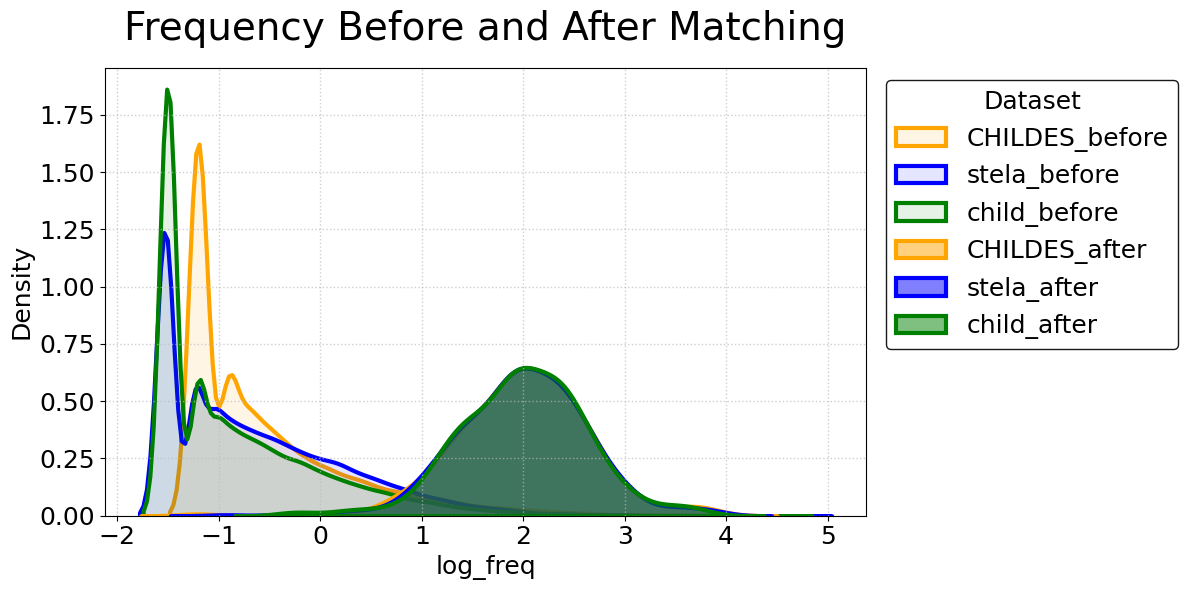

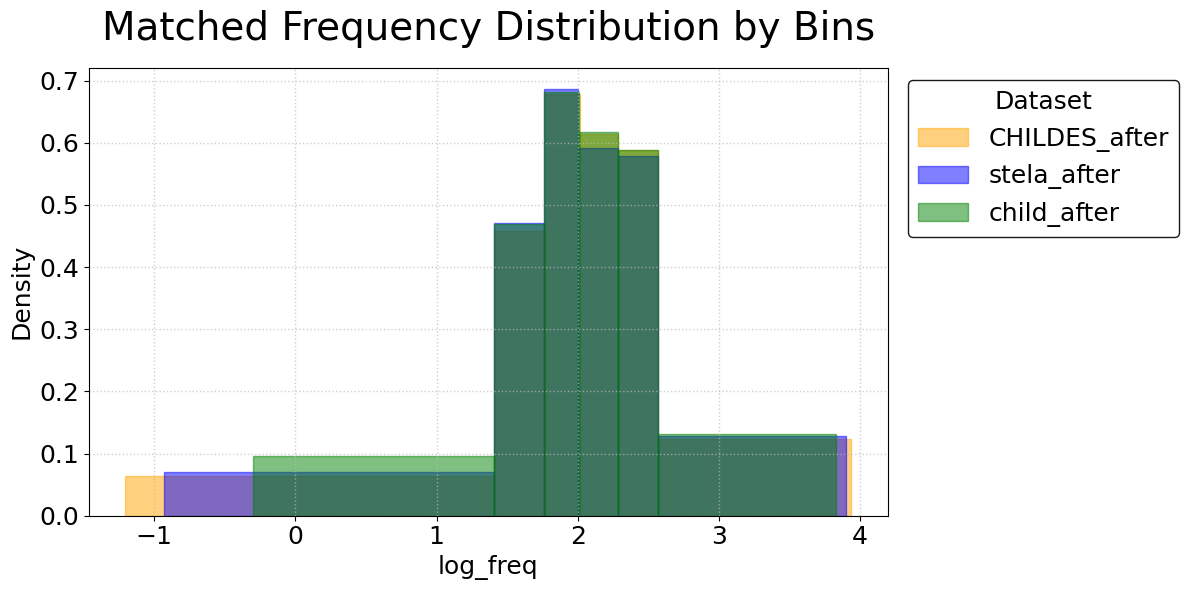

In [69]:
# load file
sampling_ratio = 1

file_root = Path(f"{data_root}/CDI_{sampling_ratio}")
freq_root = Path(f"{data_root}/word_freq")
cdi_path = Path(f"{data_root}/cdi_ws_na_childes.csv")
compare_freq(file_root, freq_root, cdi_path, output_dir=None)

# test CDI thresholds

In [135]:
def calculate_stat(df: pd.DataFrame, x_col: str, y_col: str) -> pd.DataFrame:
    # Group by x_col and calculate statistics
    stats = df.groupby(x_col)[y_col].agg([("mean", "mean"), ("std", "std"), ("count", "count")]).reset_index()
    # Calculate 95% confidence interval
    stats["ci"] = 1.96 * stats["std"] / np.sqrt(stats["count"])
    return stats


def plot_combined_cdi_curves(human_cdi_path: Path, threshold_path: Path) -> plt.Figure:
    """Plot human CDI development and threshold curves in the same figure."""
    # Create single figure
    fig, ax = plt.subplots(figsize=PlotSettings.DEFAULTS["figsize"])

    # First plot the threshold curves
    df_threshold = pd.read_csv(threshold_path)
    threshold_cols = [col for col in df_threshold.columns if col.startswith("threshold_")]

    threshold_colors = PlotSettings.get_color_palette(len(threshold_cols))

    # Plot threshold curves
    for threshold, color in zip(threshold_cols, threshold_colors):
        stats = calculate_stat(df_threshold, "month", threshold)
        threshold_value = threshold.split("_")[1]

        ax.plot(stats["month"], stats["mean"], label=f"threshold {threshold_value}", color=color, linewidth=PlotSettings.DEFAULTS["linewidth"], linestyle="--")

        ax.fill_between(stats["month"], stats["mean"] - stats["ci"], stats["mean"] + stats["ci"], alpha=0.1, color=color)

    # Plot human CDI development
    df_human = pd.read_csv(human_cdi_path)
    month_cols = [col for col in df_human.columns if (str(col).strip().isnumeric() and int(str(col).strip()) >= 16 and int(str(col).strip()) <= 30)]
    month_cols.sort(key=lambda x: int(x))

    monthly_means = df_human[month_cols].mean()
    monthly_std = df_human[month_cols].std()
    months = [int(col) for col in month_cols]

    # Plot human data
    human_color = "#FF0000"  # Red for human data
    ax.plot(months, monthly_means.values, linewidth=PlotSettings.DEFAULTS["linewidth"], color=human_color, marker="o", label="Human CDI", linestyle="-")

    # Add human confidence interval
    ci = 1.96 * monthly_std / np.sqrt(len(df_human))
    ax.fill_between(months, monthly_means - ci, monthly_means + ci, alpha=0.2, color=human_color)

    # Apply styling
    ax.set_xlabel("Month", fontsize=PlotSettings.DEFAULTS["label_fontsize"])
    ax.set_ylabel("CDI Score", fontsize=PlotSettings.DEFAULTS["label_fontsize"])
    ax.legend(
        fontsize=PlotSettings.DEFAULTS["label_fontsize"], bbox_to_anchor=(1.05, 1), loc="upper left", title="Data Sources", title_fontsize=PlotSettings.DEFAULTS["label_fontsize"]
    )

    # Apply PlotSettings style
    PlotSettings.apply_style_to_axis(ax, "CDI count-threshold")

    plt.tight_layout()
    return fig


# Core metrics

In [182]:
def plot_curves(
    df: pd.DataFrame, 
    x_header: str, 
    y_header: str,
    group_header: str, 
    y_lim: list[float] = [0, 1],
    out_path: Path | None = None
) -> None:
    """Plot multiple curves by different groups with confidence intervals."""
    plt.figure(figsize=PlotSettings.DEFAULTS["figsize"])
    df_stats = DataLoader.calculate_statistics(df, [group_header], x_header, y_header)
    unique_conditions = df_stats[group_header].unique()
    for condition in unique_conditions:
        subset = df_stats[df_stats[group_header] == condition]
        plot_condition_curve(subset, condition, x_header,y_header="mean")

    configure_plot_style(
        x_label = x_header,
        y_label = y_header,
        fig_title = f"{y_header} by months",
        legend_title= "Setting",
        grid=True,
        out_path=out_path,
        ylim = y_lim
        )


def compare_metrics(raw_data_path: str):
    """Load data and plot final results."""
    # load data
    raw_data = pd.read_csv(raw_data_path)
    df = raw_data.dropna()
    # Sort by month and combine dataset + model_type for labels
    df = df.sort_values("month")
    df["condition"] = df["dataset"] + "(" + df["model_type"] + ")"

    metric_dict = {"type_token_ratio": [0, 1], "rej_type_rate": [0, 1], "rej_token_rate": [0, 1], "CDI": [0, 1]}
    for metric, ylim in metric_dict.items():
        sel_df = DataLoader.load_df(df, metric=metric,temp=1.0)
        plot_curves(
            df = sel_df,
            x_header = "month",
            y_header = metric, 
            group_header = "condition",
            y_lim=ylim)


/var/folders/c2/336gdlh133qfynjgt7nm9jhw0000gn/T/ipykernel_60506/3361078104.py:96: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[metric] = df[metric].fillna(method="ffill")


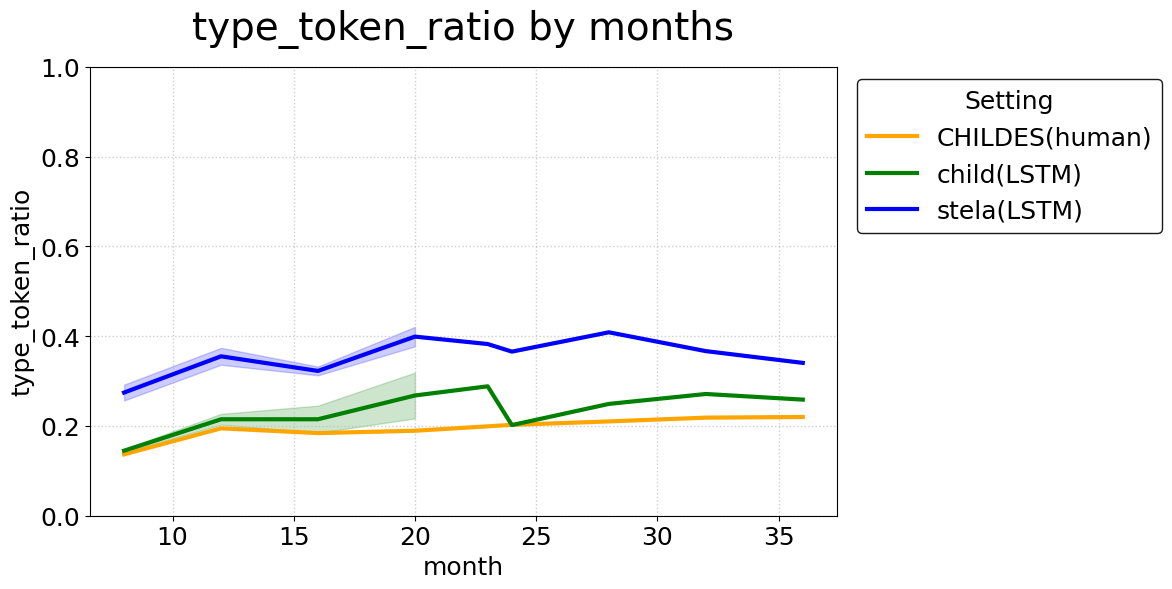

/var/folders/c2/336gdlh133qfynjgt7nm9jhw0000gn/T/ipykernel_60506/3361078104.py:96: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[metric] = df[metric].fillna(method="ffill")


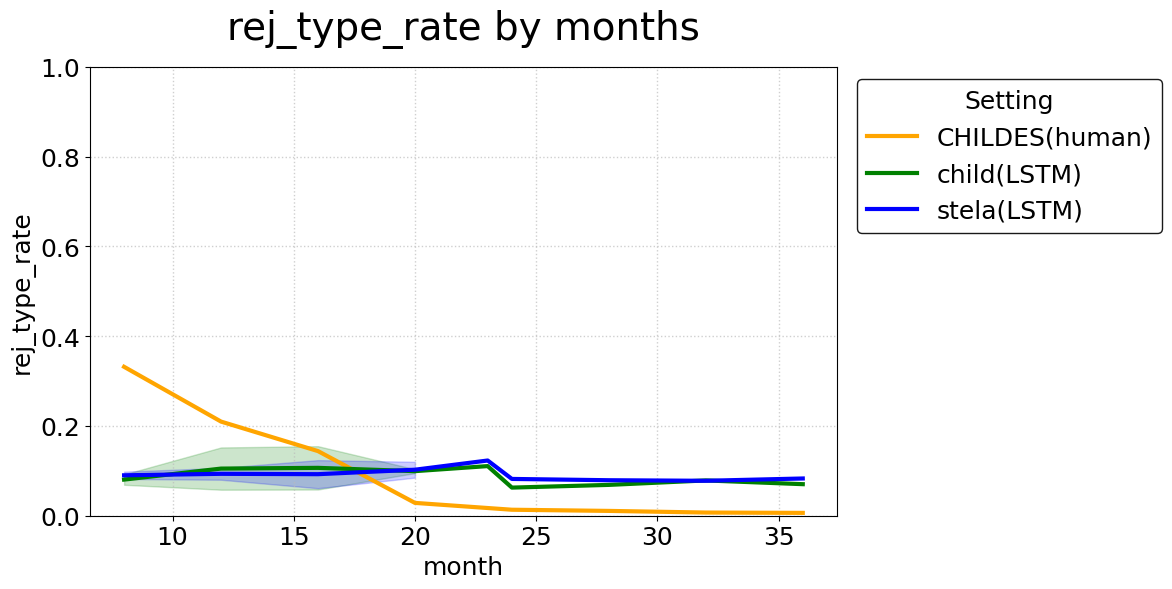

/var/folders/c2/336gdlh133qfynjgt7nm9jhw0000gn/T/ipykernel_60506/3361078104.py:96: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[metric] = df[metric].fillna(method="ffill")


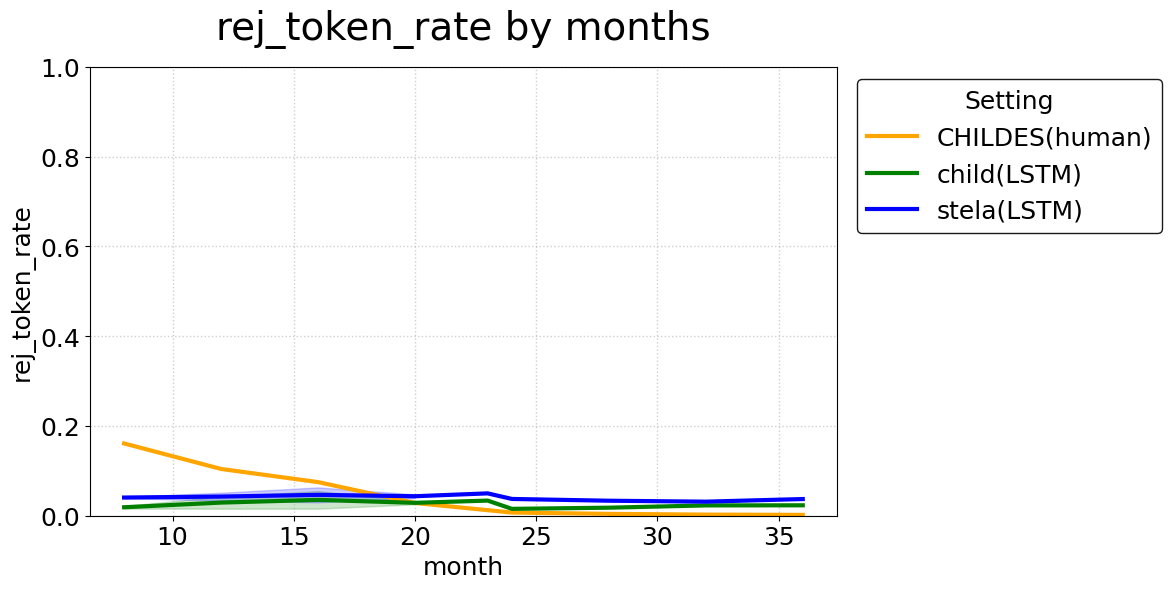

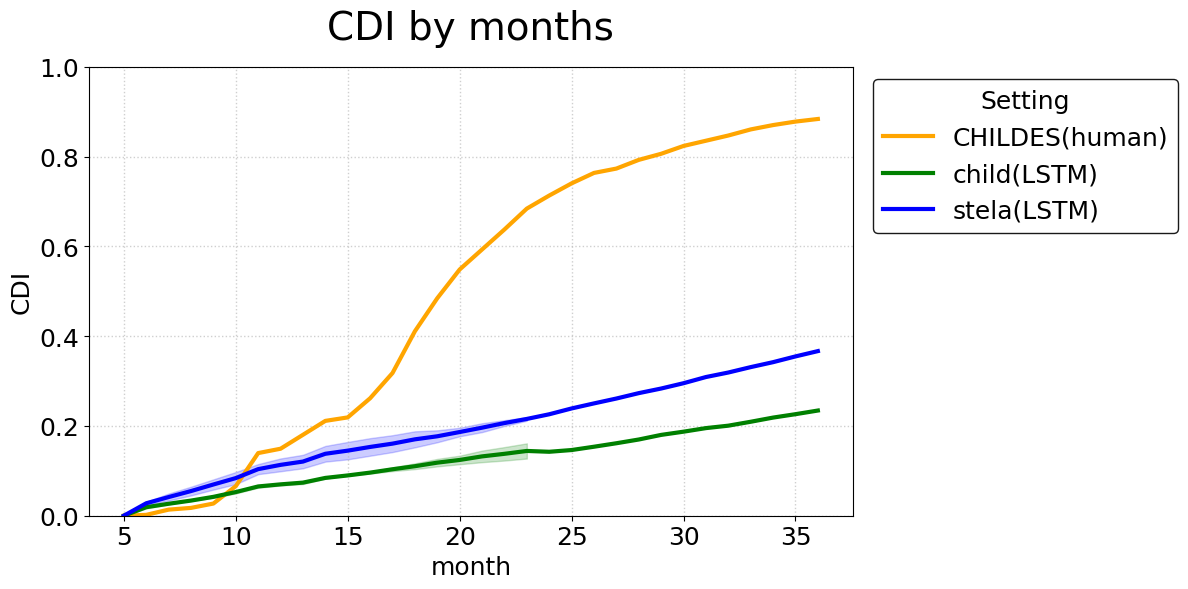

In [183]:
sampling_ratio = 1
raw_data_path = f"/Users/jliu/workspace/lexical_bencmark/dataset/CDI_{sampling_ratio}/metric_1000_4.csv"
compare_metrics(raw_data_path)

# Temperature trade-off 

In [197]:
def plot_scatters(
    df: pd.DataFrame,
    x_header: str,
    y_header: str,
    group_header: str,
    y_lim: list[float] = [0, 1],
    out_path: Path | None = None
) -> None:
    """Plot multiple curves by different groups with confidence intervals."""
    plt.figure(figsize=PlotSettings.DEFAULTS["figsize"])
    df_stats = DataLoader.calculate_statistics(df, [group_header,'temp'], x_header, y_header)
    unique_conditions = df_stats[group_header].unique()

    for condition in unique_conditions:
        subset = df_stats[df_stats[group_header] == condition]
        plot_condition_scatter(subset, condition, x_header, y_header="mean")

    configure_plot_style(
        x_label=x_header,
        y_label=y_header,
        fig_title=f"{y_header} by months",
        legend_title="Dataset",
        grid=True,
        out_path=out_path,
        ylim=y_lim
    )


def compare_temp(raw_data_path: str):
    """Load data and plot final results."""
    # load data
    raw_data = pd.read_csv(raw_data_path)
    df = raw_data.dropna()
    # Sort by month and combine dataset + model_type for labels
    df = df.sort_values("month")
    df["condition"] = df["dataset"] + "(" + df["model_type"] + ")"

    metric_dict = {"type_token_ratio": [0, 0.6], "rej_type_rate": [0, 0.4], "rej_token_rate": [0, 0.4]}
    for metric, ylim in metric_dict.items():
        sel_df = DataLoader.load_temp_df(df, x_header="CDI",y_header=metric)
        plot_scatters(
            df = sel_df,
            x_header = "CDI",
            y_header = metric, 
            group_header = "condition", 
            y_lim=ylim)


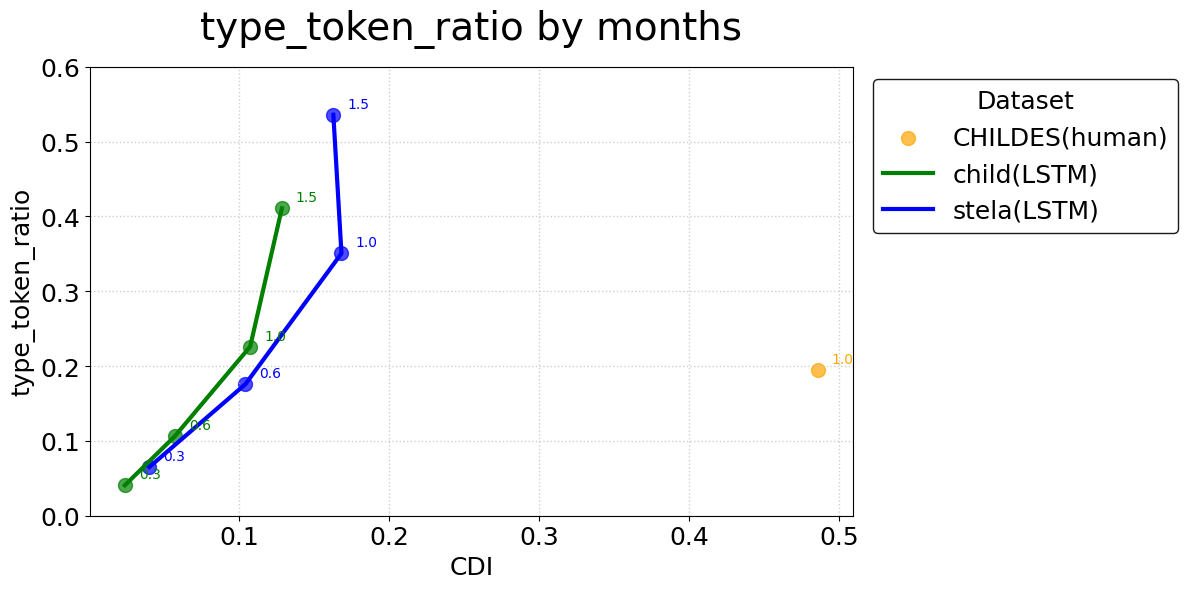

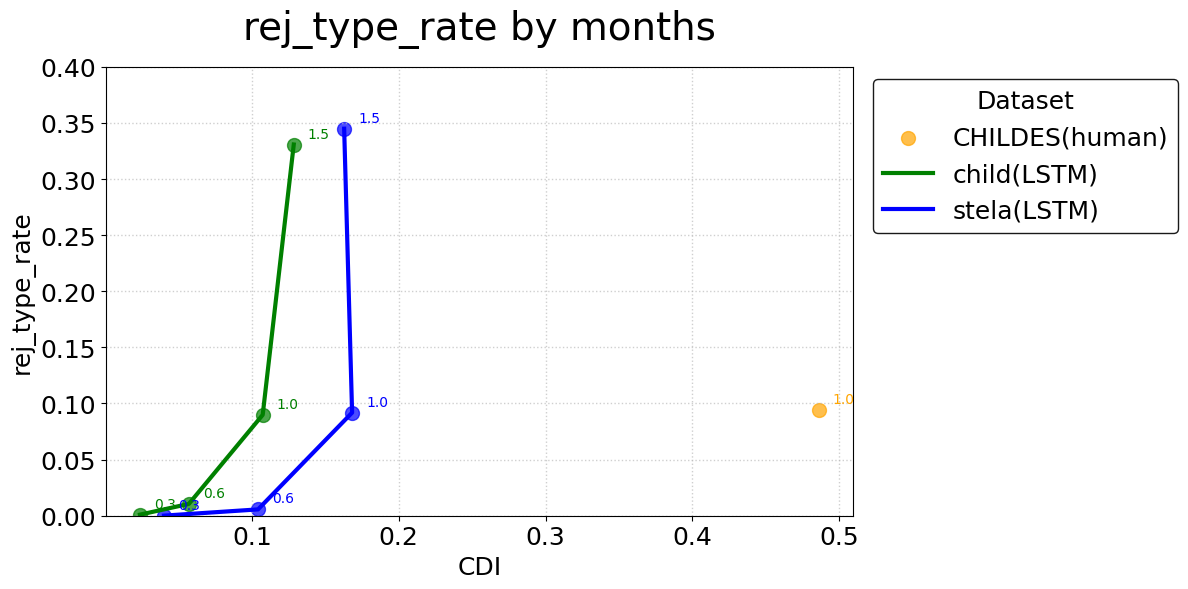

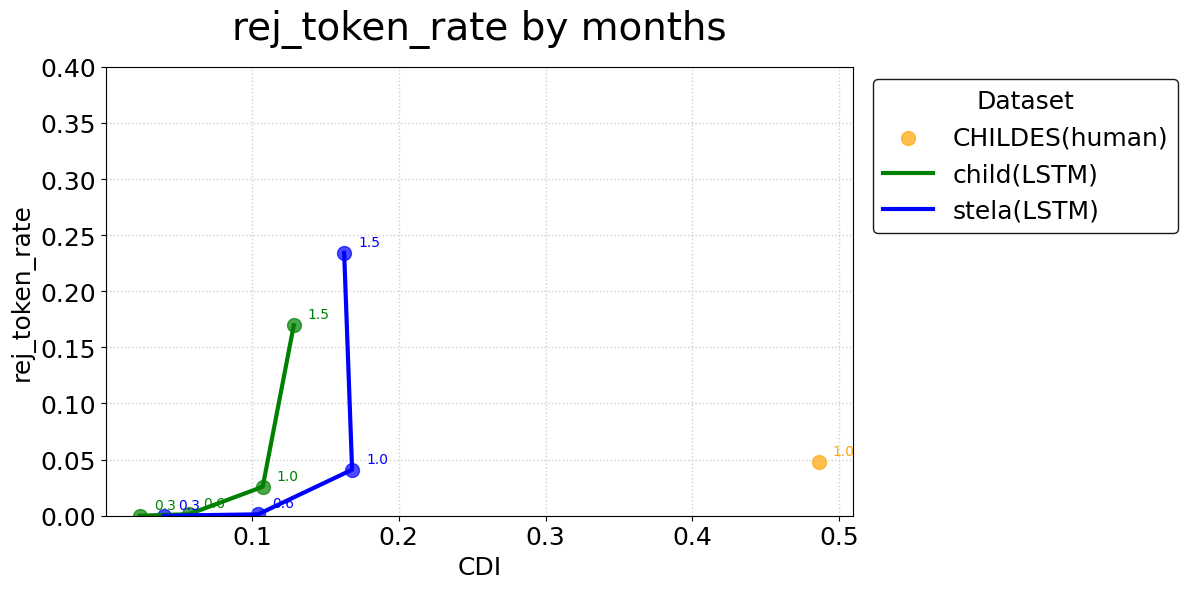

In [198]:
sampling_ratio = 1
raw_data_path = f"/Users/jliu/workspace/lexical_bencmark/dataset/CDI_{sampling_ratio}/metric_1000_4.csv"
compare_temp(raw_data_path)

# Extrapolated metrics

In [ ]:
class SigmoidExtrapolation:
    """Sigmoid curve fitting and extrapolation analysis."""

    def __init__(self, x_data: list[float], y_data: list[float], target_y: float):
        """Initialize with data and target value."""
        self.x_data = np.array(x_data)
        self.y_data = np.array(y_data)
        self.target_y = target_y
        self.params: dict[str, t.Any] = {}

    def sigmoid(self, x: np.ndarray, k: float, x0: float) -> np.ndarray:
        """Compute normalized sigmoid function."""
        return 1 / (1 + np.exp(-k * (x - x0)))

    def fit_sigmoid(self) -> dict[str, float]:
        """Fit sigmoid curve and find target value."""
        # Initial parameter estimation
        y_mid = (max(self.y_data) - min(self.y_data)) / 2 + min(self.y_data)
        x0_init = self.x_data[np.argmin(np.abs(self.y_data - y_mid))]

        mid_idx = np.argmin(np.abs(self.x_data - x0_init))
        if mid_idx > 0 and mid_idx < len(self.x_data) - 1:
            dy = self.y_data[mid_idx + 1] - self.y_data[mid_idx - 1]
            dx = self.x_data[mid_idx + 1] - self.x_data[mid_idx - 1]
            k_init = (dy / dx) * 4
        else:
            k_init = 0.1

        # Fit curve
        p0 = [k_init, x0_init]
        bounds = (
            (0.001, 2.0),
            (min(self.x_data), max(self.x_data) * 1.5),
        )

        popt, _ = curve_fit(self.sigmoid, self.x_data, self.y_data, p0=p0, bounds=bounds, maxfev=100000, method="trf")

        # Generate fitted points
        x_fit = np.linspace(0, max(self.x_data), 100)
        y_fit = self.sigmoid(x_fit, *popt)

        # Extrapolate if needed
        if max(self.y_data) < self.target_y:
            x_fit, y_fit = self._extrapolate_to_target(x_fit, y_fit, popt)

        # Find target point
        target_y_index = np.argmin(np.abs(y_fit - self.target_y))
        target_x = x_fit[target_y_index]

        self.params = {"x_fit": x_fit, "y_fit": y_fit, "target_x": target_x, "k": popt[0], "x0": popt[1]}

        return {"target_x": target_x, "k": popt[0], "x0": popt[1]}

    def _extrapolate_to_target(self, x_fit: np.ndarray, y_fit: np.ndarray, popt: tuple[float, float]) -> tuple[np.ndarray, np.ndarray]:
        """Extrapolate fitted curve to reach target value."""
        while y_fit[-1] < self.target_y:
            next_x = x_fit[-1] + (x_fit[1] - x_fit[0])
            x_fit = np.append(x_fit, next_x)
            y_fit = np.append(y_fit, self.sigmoid(next_x, *popt))

            if y_fit[-1] >= self.target_y or len(x_fit) > 1000:
                break

        return x_fit, y_fit

    def plot_curve(self, title: str = "Sigmoid Curve with Extrapolation", output_path: Path | None = None) -> None:
        """Plot the fitted sigmoid curve with extrapolation."""
        if not self.params:
            self.fit_sigmoid()

        plt.figure(figsize=(12, 8))

        # Plot original data
        plt.scatter(self.x_data, self.y_data, color="blue", alpha=0.5, label="Original Data")

        # Plot fitted curve
        plt.plot(self.params["x_fit"], self.params["y_fit"], "r-", label="Fitted Curve", linewidth=2)

        # Plot target line and point
        plt.axhline(y=self.target_y, color="green", linestyle="--", alpha=0.5, label=f"Target Value ({self.target_y:.2f})")
        plt.scatter(self.params["target_x"], self.target_y, color="green", marker="*", s=200, label=f"Target Point (x={self.params['target_x']:.2f})")

        # Configure plot
        plt.grid(True, linestyle=":")
        plt.title(title, fontsize=14)
        plt.xlabel("X Value", fontsize=12)
        plt.ylabel("Y Value", fontsize=12)
        plt.legend(fontsize=10)
        plt.ylim(-0.1, 1.1)

        if output_path:
            plt.savefig(output_path, bbox_inches="tight", dpi=300)
            plt.close()
        else:
            plt.show()


In [31]:
class SigmoidFitter:
    """Fit and plot sigmoid curves with extrapolation to target value."""

    def __init__(self, x_data: list[float], y_data: list[float], target_y: float) -> None:
        """Initialize the sigmoid fitter with data and target."""
        self.x_data = np.array(x_data)
        self.y_data = np.array(y_data)
        self.target_y = target_y
        self.params: dict[str, t.Any] = {}

    def sigmoid(self, x: np.ndarray, k: float, x0: float) -> np.ndarray:
        """
        Compute normalized sigmoid function: 1/(1 + exp(-k*(x-x0)))

        Args:
            x: Input values
            k: Steepness of the curve
            x0: x-value of sigmoid midpoint
        Returns:
            y: Values in range [0,1]
        """
        return 1 / (1 + np.exp(-k * (x - x0)))

    def estimate_initial_params(self) -> tuple[list[float], tuple[tuple[float, float], ...]]:
        """Estimate initial parameters and bounds for curve fitting."""
        # Estimate x0 (midpoint)
        y_mid = (max(self.y_data) - min(self.y_data)) / 2 + min(self.y_data)
        x0_init = self.x_data[np.argmin(np.abs(self.y_data - y_mid))]

        # Estimate k (steepness)
        mid_idx = np.argmin(np.abs(self.x_data - x0_init))
        if mid_idx > 0 and mid_idx < len(self.x_data) - 1:
            dy = self.y_data[mid_idx + 1] - self.y_data[mid_idx - 1]
            dx = self.x_data[mid_idx + 1] - self.x_data[mid_idx - 1]
            k_init = (dy / dx) * 4  # Scale factor for sigmoid shape
        else:
            k_init = 0.1

        # Initial parameter guesses
        p0 = [k_init, x0_init]

        # Parameter bounds
        bounds = (
            (0.001, 2.0),  # k bounds: shallow to steep
            (min(self.x_data), max(self.x_data) * 1.5),  # x0 bounds
        )

        return p0, bounds

    def fit_sigmoid(self) -> dict[str, float]:
        """Fit sigmoid and find target x value."""
        # Get initial parameters and bounds
        p0, bounds = self.estimate_initial_params()

        # Fit sigmoid curve with bounds and initial guesses
        popt, _ = curve_fit(self.sigmoid, self.x_data, self.y_data, p0=p0, bounds=bounds, maxfev=100000, method="trf")

        # Generate fitted points with finer resolution
        x_fit = np.linspace(0, max(self.x_data), 100)
        y_fit = self.sigmoid(x_fit, *popt)

        # Extrapolate if needed
        if max(self.y_data) < self.target_y:
            while y_fit[-1] < self.target_y:
                next_x = x_fit[-1] + (x_fit[1] - x_fit[0])
                x_fit = np.append(x_fit, next_x)
                y_fit = np.append(y_fit, self.sigmoid(next_x, *popt))

                if y_fit[-1] >= self.target_y or len(x_fit) > 1000:
                    break

        # Find target point
        target_y_index = np.argmin(np.abs(y_fit - self.target_y))
        target_x = x_fit[target_y_index]

        self.params = {"x_fit": x_fit, "y_fit": y_fit, "target_x": target_x, "k": popt[0], "x0": popt[1]}

        return {"target_x": target_x, "k": popt[0], "x0": popt[1]}

    def plot_curve(self, title: str = "Sigmoid Curve with Extrapolation", output_path: Path | None = None) -> None:
        """Plot the fitted sigmoid curve with extrapolation."""
        if not self.params:
            self.fit_sigmoid()

        plt.figure(figsize=(12, 8))

        # Plot original data points
        plt.scatter(self.x_data, self.y_data, color="blue", alpha=0.5, label="Original Data")

        # Plot fitted curve
        plt.plot(self.params["x_fit"], self.params["y_fit"], "r-", label="Fitted Curve", linewidth=2)

        # Plot target line and point
        plt.axhline(y=self.target_y, color="green", linestyle="--", alpha=0.5, label=f"Target Value ({self.target_y:.2f})")
        plt.scatter(self.params["target_x"], self.target_y, color="green", marker="*", s=200, label=f"Target Point (x={self.params['target_x']:.2f})")

        # Customize plot
        plt.grid(True, linestyle=":")
        plt.title(title, fontsize=14)
        plt.xlabel("X Value", fontsize=12)
        plt.ylabel("Y Value", fontsize=12)
        plt.legend(fontsize=10)
        plt.ylim(-0.1, 1.1)  # Set y-axis limits to show full [0,1] range

        plt.tight_layout()
        if output_path:
            plt.savefig(output_path, bbox_inches="tight", dpi=300)
            plt.close()
        else:
            plt.show()
